=== BASELINE LOGISTIC REGRESSION ===
Accuracy: 0.772
F1 Score: 0.7864
Runtime: 0.14 seconds
------------------------------------------------------------
--- Tuning Parameter Set 1 ---
Best Params: {'C': 0.5, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.7824, F1 Score: 0.8, Runtime: 3.64s

--- Tuning Parameter Set 2 ---
Best Params: {'C': 2.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.772, F1 Score: 0.7864, Runtime: 1.08s

--- Tuning Parameter Set 3 ---
Best Params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.7979, F1 Score: 0.8116, Runtime: 0.76s



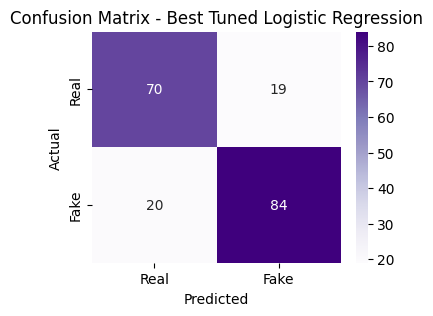


=== LOGISTIC REGRESSION MODEL COMPARISON ===
        Set                                        Best Params  Accuracy  \
0  Baseline                                            Default    0.7720   
1         1     {'C': 0.5, 'penalty': 'l2', 'solver': 'lbfgs'}    0.7824   
2         2     {'C': 2.0, 'penalty': 'l2', 'solver': 'lbfgs'}    0.7720   
3         3  {'C': 0.1, 'penalty': 'l1', 'solver': 'libline...    0.7979   

   F1 Score  Runtime (s)  
0    0.7864         0.14  
1    0.8000         3.64  
2    0.7864         1.08  
3    0.8116         0.76  

=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===
[0.77844311 0.82634731 0.83229814 0.875      0.7388535 ]
Mean F1 Score: 0.8102


In [3]:
# MODEL 3: LOGISTIC REGRESSION

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer # Import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("final_preprocessed_vectorized.csv")

# Define features (TF-IDF columns) and target ('class')
tfidf_cols = [c for c in df.columns if c.startswith('tfidf_')]
X = df[tfidf_cols]
y = df['class']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Impute missing values with the mean
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# Feature scaling
scaler = StandardScaler(with_mean=False)  # with_mean=False because sparse matrix
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Baseline Logistic Regression
lr_base = LogisticRegression(max_iter=500, solver='lbfgs', random_state=42)
start = time.time()
lr_base.fit(X_train_s, y_train)
yp_base = lr_base.predict(X_test_s)
end = time.time()
baseline_runtime = round(end - start, 2)

print("=== BASELINE LOGISTIC REGRESSION ===")
print("Accuracy:", round(accuracy_score(y_test, yp_base), 4))
print("F1 Score:", round(f1_score(y_test, yp_base), 4))
print("Runtime:", baseline_runtime, "seconds")
print("-" * 60)

# Parameter tunings
param_sets = [
    {'C': [0.5, 1.0], 'penalty': ['l2'], 'solver': ['lbfgs']},
    {'C': [2.0, 5.0], 'penalty': ['l2'], 'solver': ['lbfgs']},
    {'C': [0.1, 0.5, 1.0], 'penalty': ['l1'], 'solver': ['liblinear']}  # l1 requires liblinear
]

best_score = 0
best_model = None
best_params = None
tuning_results = []

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for i, params in enumerate(param_sets, 1):
    print(f"--- Tuning Parameter Set {i} ---")
    lr = LogisticRegression(max_iter=500, random_state=42)
    start = time.time()
    grid = GridSearchCV(lr, params, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train_s, y_train)
    end = time.time()
    runtime = round(end - start, 2)

    yp = grid.predict(X_test_s)
    acc = accuracy_score(y_test, yp)
    f1 = f1_score(y_test, yp)

    tuning_results.append({
        'Set': i,
        'Best Params': grid.best_params_,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4),
        'Runtime (s)': runtime
    })

    print(f"Best Params: {grid.best_params_}")
    print(f"Accuracy: {round(acc,4)}, F1 Score: {round(f1,4)}, Runtime: {runtime}s\n")

    if f1 > best_score:
        best_score = f1
        best_model = grid.best_estimator_
        best_params = grid.best_params_

# Confusion Matrix for Best Tuned Model
yp_best = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, yp_best)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title("Confusion Matrix - Best Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Model Comparison Table
import pandas as pd
comparison_df = pd.DataFrame(tuning_results)
baseline_row = pd.DataFrame([{
    'Set': 'Baseline',
    'Best Params': 'Default',
    'Accuracy': round(accuracy_score(y_test, yp_base),4),
    'F1 Score': round(f1_score(y_test, yp_base),4),
    'Runtime (s)': baseline_runtime
}])
comparison_df = pd.concat([baseline_row, comparison_df], ignore_index=True)
print("\n=== LOGISTIC REGRESSION MODEL COMPARISON ===")
print(comparison_df)

#  Cross-validation on Best Tuned Model
cv_scores = cross_val_score(best_model, X_train_s, y_train, cv=5, scoring='f1')
print("\n=== CROSS-VALIDATION F1 SCORES (Best Tuned Model) ===")
print(cv_scores)
print("Mean F1 Score:", round(np.mean(cv_scores), 4))